## Importing the libraries

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the dataset

In [11]:
dataset = pd.read_csv("sentiment_dataset.csv")
print(dataset.head())

   Unnamed: 0.1  Unnamed: 0  \
0             0           0   
1             1           1   
2             2           2   
3             3           3   
4             4           4   

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes     

## Basic cleaning

In [12]:
dataset = dataset.drop(columns = ["Unnamed: 0.1", "Unnamed: 0"])
print(dataset.head())

                                                Text    Sentiment  \
0   Enjoying a beautiful day at the park!        ...   Positive     
1   Traffic was terrible this morning.           ...   Negative     
2   Just finished an amazing workout! 💪          ...   Positive     
3   Excited about the upcoming weekend getaway!  ...   Positive     
4   Trying out a new recipe for dinner tonight.  ...   Neutral      

             Timestamp            User     Platform  \
0  2023-01-15 12:30:00   User123          Twitter     
1  2023-01-15 08:45:00   CommuterX        Twitter     
2  2023-01-15 15:45:00   FitnessFan      Instagram    
3  2023-01-15 18:20:00   AdventureX       Facebook    
4  2023-01-15 19:55:00   ChefCook        Instagram    

                                     Hashtags  Retweets  Likes       Country  \
0   #Nature #Park                                  15.0   30.0     USA         
1   #Traffic #Morning                               5.0   10.0     Canada      
2   #Fitness #

In [14]:
dataset['Sentiment'] = dataset['Sentiment'].str.strip()
dataset['User'] = dataset['User'].str.strip()
dataset['Platform'] = dataset['Platform'].str.strip()
dataset['Country'] = dataset['Country'].str.strip()

print(dataset.info())
print(dataset.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Text       732 non-null    object 
 1   Sentiment  732 non-null    object 
 2   Timestamp  732 non-null    object 
 3   User       732 non-null    object 
 4   Platform   732 non-null    object 
 5   Hashtags   732 non-null    object 
 6   Retweets   732 non-null    float64
 7   Likes      732 non-null    float64
 8   Country    732 non-null    object 
 9   Year       732 non-null    int64  
 10  Month      732 non-null    int64  
 11  Day        732 non-null    int64  
 12  Hour       732 non-null    int64  
dtypes: float64(2), int64(4), object(7)
memory usage: 74.5+ KB
None
Text         0
Sentiment    0
Timestamp    0
User         0
Platform     0
Hashtags     0
Retweets     0
Likes        0
Country      0
Year         0
Month        0
Day          0
Hour         0
dtype: int64


## Summary statistics - numerical columns

In [15]:
num_cols = ["Retweets", "Likes", "Year", "Month", "Day", "Hour"]
print("\nSummary Statistics:")
print(dataset.describe().round(2))
print("\nMedians:")
print(dataset[num_cols].median().round(2))
print("\nMode:")
print(dataset.mode().iloc[0])


Summary Statistics:
       Retweets   Likes     Year   Month     Day    Hour
count    732.00  732.00   732.00  732.00  732.00  732.00
mean      21.51   42.90  2020.47    6.12   15.50   15.52
std        7.06   14.09     2.80    3.41    8.47    4.11
min        5.00   10.00  2010.00    1.00    1.00    0.00
25%       17.75   34.75  2019.00    3.00    9.00   13.00
50%       22.00   43.00  2021.00    6.00   15.00   16.00
75%       25.00   50.00  2023.00    9.00   22.00   19.00
max       40.00   80.00  2023.00   12.00   31.00   23.00

Medians:
Retweets      22.0
Likes         43.0
Year        2021.0
Month          6.0
Day           15.0
Hour          16.0
dtype: float64

Mode:
Text          A compassionate rain, tears of empathy fallin...
Sentiment                                             Positive
Timestamp                                  2018-08-22 17:20:00
User                                                  Bookworm
Platform                                             Instagram
Hasht

## Sentiment distribution

\Top 15 Sentiments
Sentiment
Positive       45
Joy            44
Excitement     37
Contentment    19
Neutral        18
Gratitude      18
Curiosity      16
Serenity       15
Happy          14
Nostalgia      11
Despair        11
Grief           9
Awe             9
Sad             9
Hopeful         9
Name: count, dtype: int64


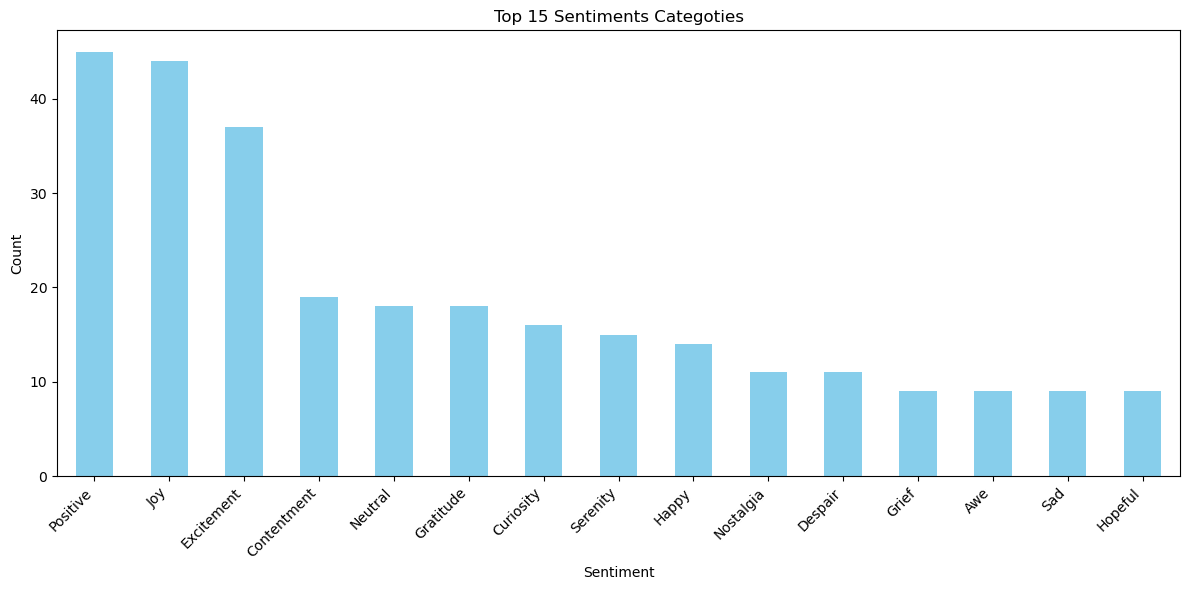

In [19]:
print("\Top 15 Sentiments")
sentiment_counts = dataset["Sentiment"].value_counts().head(15)
print(sentiment_counts)

plt.figure(figsize = (12,6))
sentiment_counts.plot(kind = "bar", color = "skyblue")
plt.title("Top 15 Sentiments Categoties")
plt.ylabel('Count')
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

## Distributions of Likes & Retweets

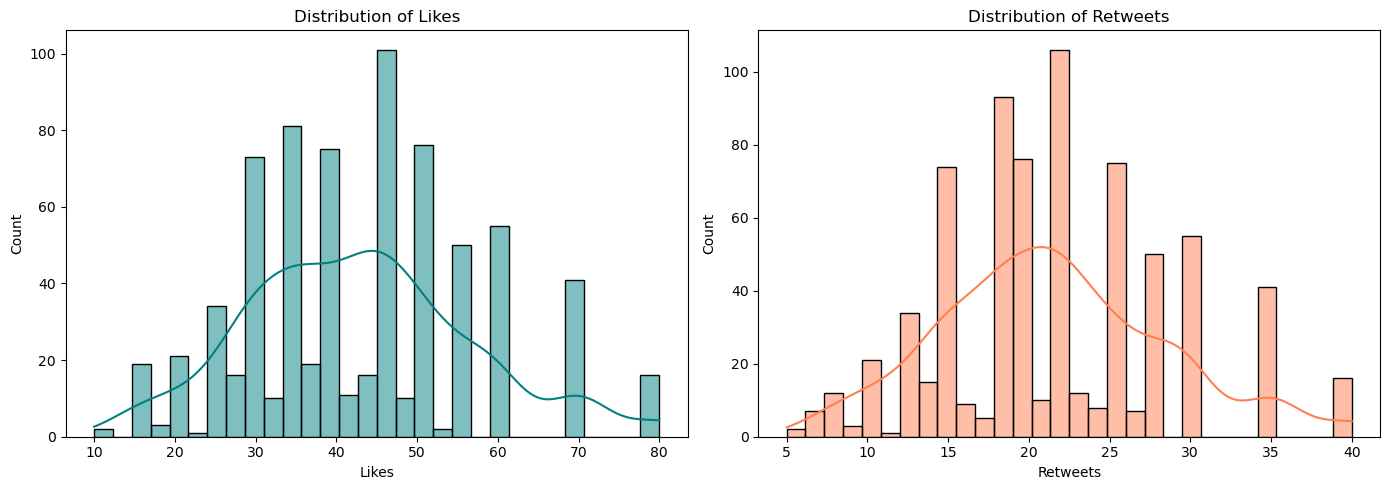

In [22]:
plt.figure(figsize = (14,5))

plt.subplot(1,2,1)
sns.histplot(dataset["Likes"], kde = True, bins = 30, color = "teal")
plt.title("Distribution of Likes")
plt.xlabel("Likes")

plt.subplot(1,2,2)
sns.histplot(dataset["Retweets"], kde = True, bins = 30, color = "coral")
plt.title("Distribution of Retweets")
plt.xlabel("Retweets")

plt.tight_layout()
plt.show()

## Likes by Sentiment (boxplot - top sentiments)

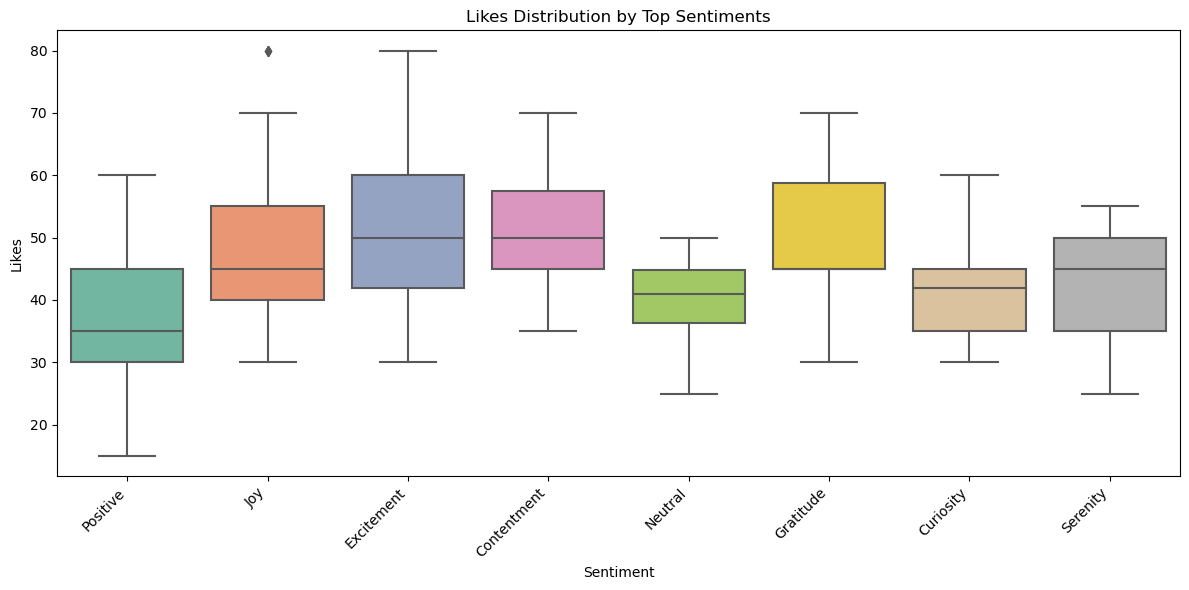

In [23]:
top_sentiments = dataset["Sentiment"].value_counts().head(8).index

plt.figure(figsize = (12,6))
sns.boxplot(x = "Sentiment", y = "Likes", data = dataset[dataset["Sentiment"].isin(top_sentiments)], order = top_sentiments, palette = "Set2")
plt.title("Likes Distribution by Top Sentiments")
plt.xticks(rotation = 45, ha = "right")
plt.tight_layout()
plt.show()

## Likes vs Retweets scatter plot (colored by Sentiment)

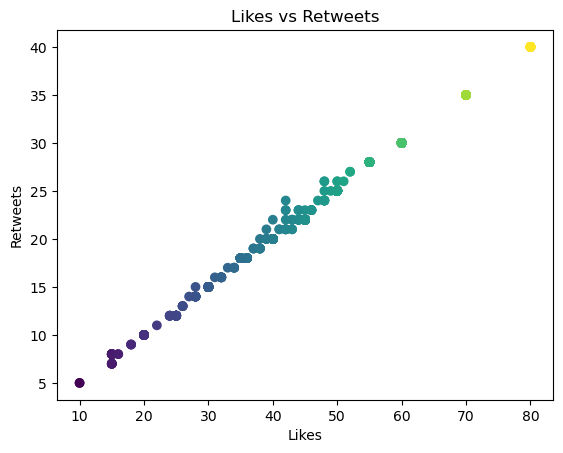

In [24]:
plt.figure()
plt.scatter(dataset["Likes"], dataset["Retweets"], c = dataset["Likes"], cmap = "viridis")
plt.title("Likes vs Retweets")
plt.xlabel("Likes")
plt.ylabel("Retweets")
plt.show()

## Correlation heatmap

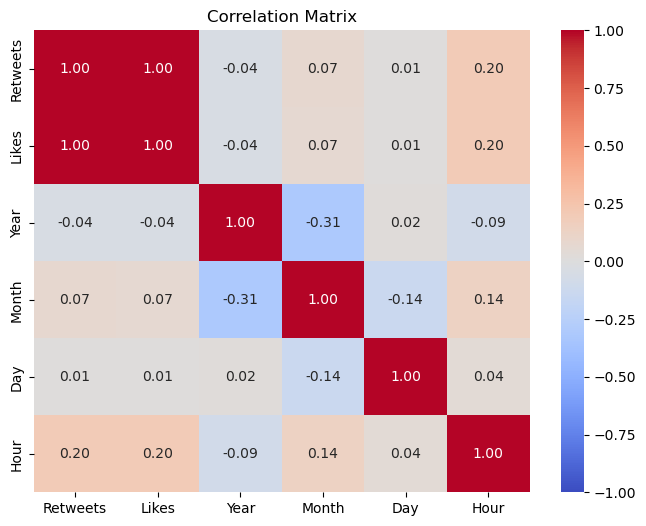

In [26]:
plt.figure(figsize=(8,6))
corr = dataset[num_cols].corr()
sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", vmin = -1, vmax = 1)
plt.title("Correlation Matrix")
plt.show()